# Compare `plot.py` functions: seaborn (old) vs matplotlib (new)

This notebook compares the previous **seaborn-based** implementations against the new
**matplotlib-only** implementations of the affected functions in `skforecast.plot`:

- `plot_residuals`
- `plot_multivariate_time_series_corr`
- `plot_prediction_distribution`

The **old** versions are redefined inline in this notebook (prefixed with `old_`), while the
**new** versions are imported from `skforecast.plot`. Run the cells to render both side by side.


In [1]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
path = str(Path.cwd().parent)
print(path)
sys.path.insert(1, path)

import numpy as np
import pandas as pd
import skforecast

print(skforecast.__version__)

/Users/javier.escobar/code/github/skforecast
0.23.0


In [2]:
# Imports and reproducible sample data
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from statsmodels.graphics.tsaplots import plot_acf

# New (matplotlib-only) implementations
from skforecast.plot import (
    plot_residuals,
    plot_multivariate_time_series_corr,
    plot_prediction_distribution,
)

rng = np.random.default_rng(123)

# Residuals
residuals = pd.Series(rng.normal(loc=0, scale=1, size=500), name="residuals")

# Correlation matrix for the heatmap
series_df = pd.DataFrame(
    rng.normal(size=(200, 5)),
    columns=[f"series_{i}" for i in range(1, 6)],
)
corr = series_df.corr()

# Bootstrapping predictions for the ridge plot (rows = steps, cols = bootstrap samples)
bootstrapping_predictions = pd.DataFrame(
    rng.normal(loc=np.arange(10)[:, None], scale=1.0, size=(10, 250)),
    index=[f"step_{i}" for i in range(1, 11)],
)

print("seaborn version:", sns.__version__)
print("matplotlib version:", matplotlib.__version__)


seaborn version: 0.13.2
matplotlib version: 3.10.8


## Old (seaborn-based) implementations

These are the original functions as they were before removing the seaborn dependency.


In [3]:
def old_plot_residuals(
    residuals=None,
    y_true=None,
    y_pred=None,
    fig=None,
    **fig_kw
):
    """Old seaborn-based version of `plot_residuals`."""

    if residuals is None and (y_true is None or y_pred is None):
        raise ValueError(
            "If `residuals` argument is None then, `y_true` and `y_pred` must be provided."
        )

    if residuals is None:
        residuals = y_true - y_pred

    if fig is None:
        fig = plt.figure(constrained_layout=True, **fig_kw)

    gs = matplotlib.gridspec.GridSpec(2, 2, figure=fig)
    ax1 = plt.subplot(gs[0, :])
    ax2 = plt.subplot(gs[1, 0])
    ax3 = plt.subplot(gs[1, 1])

    ax1.plot(residuals)
    sns.histplot(residuals, kde=True, bins=30, ax=ax2)
    plot_acf(residuals, ax=ax3, lags=60)

    ax1.set_title("Residuals")
    ax2.set_title("Distribution")
    ax3.set_title("Autocorrelation")

    return fig


def old_plot_multivariate_time_series_corr(
    corr,
    ax=None,
    **fig_kw
):
    """Old seaborn-based version of `plot_multivariate_time_series_corr`."""

    if ax is None:
        fig, ax = plt.subplots(1, 1, **fig_kw)
    else:
        fig = ax.get_figure()

    sns.heatmap(
        corr,
        annot=True,
        linewidths=.5,
        ax=ax,
        cmap=sns.color_palette("viridis", as_cmap=True)
    )

    ax.set_xlabel('Time series')

    return fig


def old_plot_prediction_distribution(
    bootstrapping_predictions,
    bw_method=None,
    **fig_kw
):
    """Old seaborn-based version of `plot_prediction_distribution`."""

    index = bootstrapping_predictions.index.astype(str).to_list()[::-1]
    palette = sns.cubehelix_palette(len(index), rot=-.25, light=.7, reverse=False)
    fig, axs = plt.subplots(len(index), 1, sharex=True, **fig_kw)
    if not isinstance(axs, np.ndarray):
        axs = np.array([axs])

    for i, step in enumerate(index):
        plot = (
            bootstrapping_predictions.loc[step, :]
            .plot.kde(ax=axs[i], bw_method=bw_method, lw=0.5)
        )

        # Fill density area
        x = plot.get_children()[0]._x
        y = plot.get_children()[0]._y
        axs[i].fill_between(x, y, color=palette[i])
        prediction_mean = bootstrapping_predictions.loc[step, :].mean()

        # Closest point on x to the prediction mean
        idx = np.abs(x - prediction_mean).argmin()
        axs[i].vlines(x[idx], ymin=0, ymax=y[idx], linestyle="dashed", color='w')

        axs[i].spines['top'].set_visible(False)
        axs[i].spines['right'].set_visible(False)
        axs[i].spines['bottom'].set_visible(False)
        axs[i].spines['left'].set_visible(False)
        axs[i].set_yticklabels([])
        axs[i].set_yticks([])
        axs[i].set_ylabel(step, rotation='horizontal')
        axs[i].set_xlabel('prediction')

    fig.subplots_adjust(hspace=-0)
    fig.suptitle('Forecasting distribution per step')

    return fig


## 1. `plot_residuals`


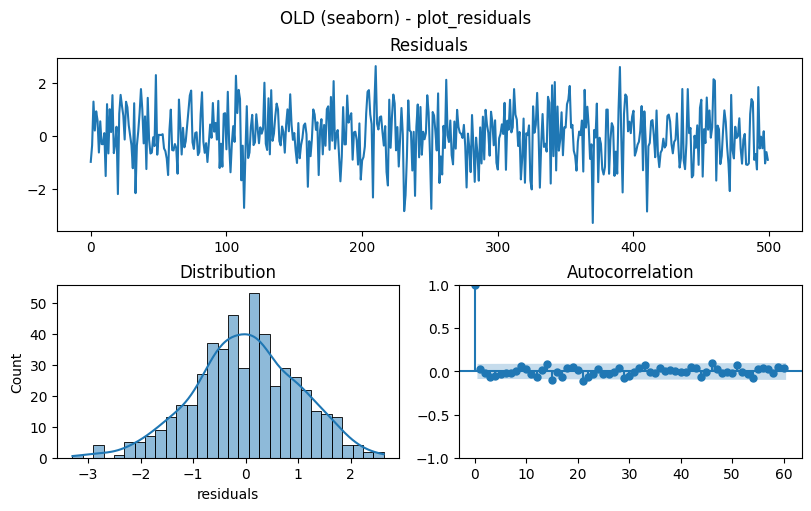

In [4]:
# Old (seaborn)
fig = old_plot_residuals(residuals=residuals, figsize=(8, 5))
fig.suptitle("OLD (seaborn) - plot_residuals")
plt.show()


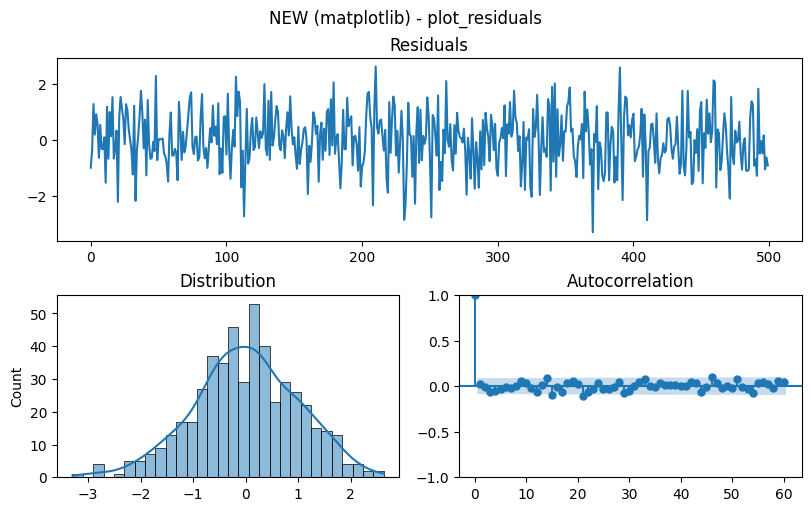

In [5]:
# New (matplotlib)
fig = plot_residuals(residuals=residuals, figsize=(8, 5))
fig.suptitle("NEW (matplotlib) - plot_residuals")
plt.show()


## 2. `plot_multivariate_time_series_corr`


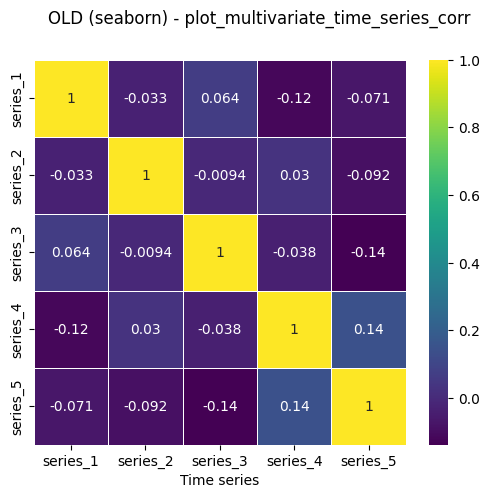

In [6]:
# Old (seaborn)
fig = old_plot_multivariate_time_series_corr(corr=corr, figsize=(6, 5))
fig.suptitle("OLD (seaborn) - plot_multivariate_time_series_corr")
plt.show()


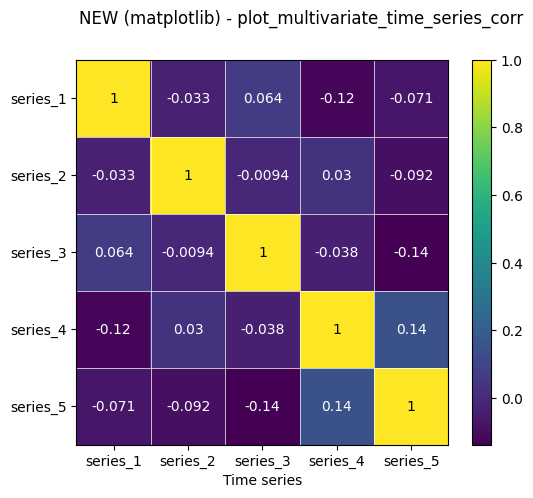

In [7]:
# New (matplotlib)
fig = plot_multivariate_time_series_corr(corr=corr, figsize=(6, 5))
fig.suptitle("NEW (matplotlib) - plot_multivariate_time_series_corr")
plt.show()


## 3. `plot_prediction_distribution`


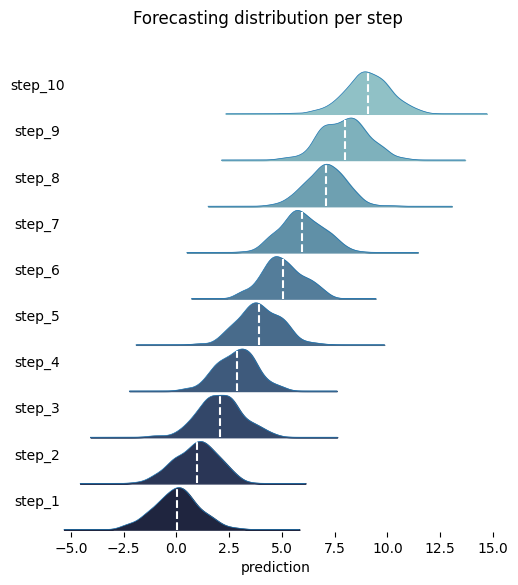

In [8]:
# Old (seaborn)
fig = old_plot_prediction_distribution(bootstrapping_predictions, figsize=(6, 6))
plt.show()


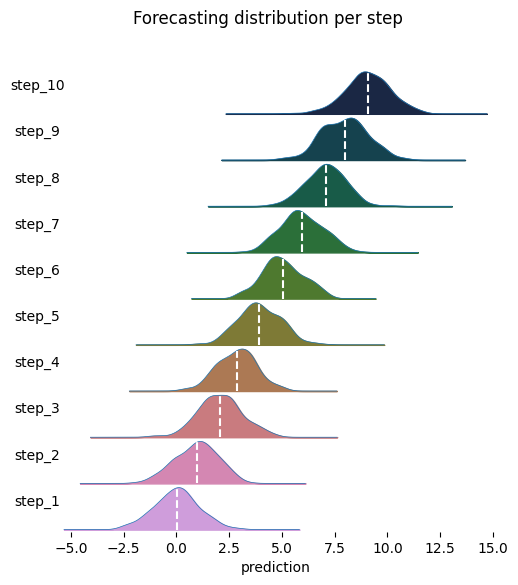

In [9]:
# New (matplotlib)
fig = plot_prediction_distribution(bootstrapping_predictions, figsize=(6, 6))
plt.show()
